
## 🛠️ 1. Import bibliotek

Ładujemy biblioteki: pandas, scikit-learn i matplotlib.

### 📖 Wytłumaczenie:
Potrzebujemy narzędzi do obróbki danych, uczenia modelu i wizualizacji.

### 💡 Ćwiczenie:
Dodaj `import random` i wylosuj 3 liczby od 1 do 100.


In [ ]:

import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns



## 📝 2. Przygotowanie przykładowych danych

Tworzymy prostą listę zgłoszeń IT bez przypisanych etykiet.

### 📖 Wytłumaczenie:
W unsupervised learning nie mamy kategorii — model sam musi je "odkryć" na podstawie podobieństw.

### 💡 Ćwiczenie:
Dodaj jedno własne zgłoszenie dotyczące internetu.


In [ ]:
texts = [
    "Problem z drukarką HP",
    "Awaria połączenia sieciowego",
    "Nie działa internet",
    "Prośba o reset hasła",
    "Zmiana ustawień konta",
    "Problem z aplikacją mobilną",
    "Reklamacja routera",
    "Brak dostępu do systemu",
    "Problem z logowaniem",
    "Aktualizacja drukarki wymaga interwencji",
    "Konfiguracja nowego routera",
    "Problemy z wydajnością sieci",
    "Prośba o przydzielenie nowego hasła",
    "Instalacja aktualizacji aplikacji",
    "Serwis drukarki Canon",
    "Brak połączenia VPN",
    "Nie można uzyskać dostępu do konta",
    "Błąd przy logowaniu do aplikacji",
    "Zgłoszenie awarii drukarki sieciowej",
    "Utrata sygnału Wi-Fi",
    "Zmiana numeru telefonu w systemie",
    "Problemy z otwieraniem plików w aplikacji",
    "Reset zapomnianego hasła",
    "Modernizacja infrastruktury sieciowej",
    "Problemy z konfiguracją drukarki HP"
]


## 🧹 3. Minimalne czyszczenie tekstu

Usuwamy duże litery i znaki specjalne, by ułatwić modelowi analizę tekstu.

### 📖 Wytłumaczenie:
Nawet bez etykiet warto zadbać o jednolitość danych, żeby grupowanie było sensowne.

### 💡 Ćwiczenie:
Dodaj usuwanie liczb (`\d`) z tekstu.


In [ ]:

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = text.strip()
    return text

texts_cleaned = [clean_text(t) for t in texts]



## 🔢 4. Zamiana tekstu na liczby (TF-IDF)

Zamieniamy teksty na macierz liczb opisujących "ważność" słów w zgłoszeniu.

### 📖 Wytłumaczenie:
Komputer rozumie liczby, nie tekst — TF-IDF pozwala mu zobaczyć, które słowa są istotne.

### 💡 Ćwiczenie:
Ustaw `max_features=20` w TF-IDF, żeby ograniczyć liczbę branych pod uwagę słów.


In [ ]:

vectorizer = TfidfVectorizer(max_features=20)
X_vec = vectorizer.fit_transform(texts_cleaned)



## 🧠 5. Grupowanie zgłoszeń metodą KMeans

Model próbuje sam znaleźć podobne grupy zgłoszeń.

### 📖 Wytłumaczenie:
KMeans przypisuje każde zgłoszenie do jednej z kilku grup na podstawie ich podobieństwa.

### 💡 Ćwiczenie:
Spróbuj zmienić liczbę grup (`n_clusters=3`) i sprawdź, czy grupowanie się zmienia.


In [ ]:

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_vec)
clusters = kmeans.labels_


## 📋 6. Wyświetlenie przypisanych grup

Zobaczymy, do której grupy trafiło każde zgłoszenie.

### 📖 Wytłumaczenie:
Model przypisał numery grup, ale my sami musimy zinterpretować, co one oznaczają.

### 💡 Ćwiczenie:
Posortuj zgłoszenia według numeru grupy (`Grupa`).


In [ ]:

df = pd.DataFrame({'Zgłoszenie': texts, 'Grupa': clusters})
df = df.sort_values(by='Grupa')
df


,Zgłoszenie,Grupa
14,Serwis drukarki Canon,0
9,Aktualizacja drukarki wymaga interwencji,0
24,Problemy z konfiguracją drukarki HP,0
18,Zgłoszenie awarii drukarki sieciowej,0
11,Problemy z wydajnością sieci,1
13,Instalacja aktualizacji aplikacji,1
2,Nie działa internet,1
7,Brak dostępu do systemu,1
19,Utrata sygnału Wi-Fi,1
23,Modernizacja infrastruktury sieciowej,1



## 📊 7. (Bonus) Wizualizacja klastrów

Szybka wizualizacja jak rozmieszczone są grupy zgłoszeń.

### 📖 Wytłumaczenie:
Za pomocą PCA sprowadzamy dane do 2D, żeby łatwiej zobaczyć różnice między grupami.

### 💡 Ćwiczenie:
Spróbuj zamienić PCA na TSNE (`from sklearn.manifold import TSNE`), żeby zobaczyć dokładniejszy podział.


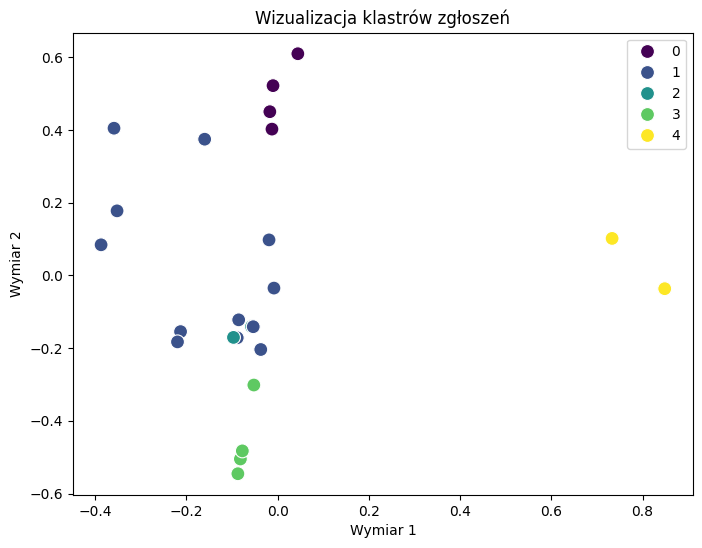

In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vec.toarray())

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="viridis", s=100)
plt.title('Wizualizacja klastrów zgłoszeń')
plt.xlabel('Wymiar 1')
plt.ylabel('Wymiar 2')
plt.show()
